## **Εισαγωγή στην Ιεραρχική Ομαδοποίηση (Hierarchical Clustering)**
Η Ιεραρχική Ομαδοποίηση είναι μια μέθοδος Μη Επιβλεπόμενης Μάθησης (Unsupervised Learning) που ομαδοποιεί δεδομένα δημιουργώντας μια δενδρική δομή, γνωστή ως Δενδροδιάγραμμα.


Σε αντίθεση με τον αλγόριθμο k-Means, εδώ δεν χρειάζεται να ορίσουμε εκ των προτέρων τον αριθμό των ομάδων (k). Μπορούμε να "κόψουμε" το δέντρο στο ύψος που επιθυμούμε για να πάρουμε τον κατάλληλο αριθμό ομάδων.


## **Οι Δύο Κύριοι Τύποι:**
**Συσσωρευτική** (Agglomerative - "Bottom-Up"): Είναι η πιο συχνή μέθοδος.


Πώς λειτουργεί: Ξεκινάμε θεωρώντας κάθε σημείο ως ένα ξεχωριστό cluster. Σε κάθε βήμα, ενώνουμε τα δύο πιο κοντινά clusters μέχρι να μείνει μόνο ένα που τα περιέχει όλα.

**Διαιρετική** (Divisive - "Top-Down"):

Είναι το αντίστροφο.

Πώς λειτουργεί: Ξεκινάμε με όλα τα σημεία σε μία τεράστια ομάδα και σταδιακά την σπάμε σε μικρότερες, μέχρι κάθε σημείο να μείνει μόνο του.

## **Πώς μετράμε την απόσταση μεταξύ ομάδων (Linkage);**
Όταν έχουμε να ενώσουμε δύο ομάδες, πώς αποφασίζουμε πόσο απέχουν;

Single Linkage: Η απόσταση καθορίζεται από τα δύο πιο κοντινά σημεία των δύο ομάδων.

Complete Linkage: Η απόσταση καθορίζεται από τα δύο πιο απομακρυσμένα σημεία.

Ward Linkage (Default): Προσπαθεί να ελαχιστοποιήσει τη διασπορά (variance) μέσα στις ομάδες. Συνήθως δίνει τα πιο ισορροπημένα αποτελέσματα.

## **ΤΟ ΠΡΟΒΛΗΜΑ**
Μια εταιρεία τηλεπικοινωνιών έχει αναλάβει να καλύψει με σήμα 5G μια νέα Βιομηχανική Περιοχή. Έχουμε τις ακριβείς συντεταγμένες 6 μεγάλων εργοστασίων.

Κάθε κεραία 5G κοστίζει ακριβά. Ο στόχος μας δεν είναι να βάλουμε μια κεραία σε κάθε εργοστάσιο, αλλά να βρούμε ποιες ομάδες εργοστασίων είναι κοντά μεταξύ τους, ώστε να τοποθετήσουμε μία κεντρική κεραία ανά ομάδα. Στόχος μας είναι να τα ομαδοποιήσουμε γεωγραφικά ώστε να τοποθετήσουμε τον ελάχιστο αριθμό κεραιών που καλύπτει τις ανάγκες τους.

**Block 1: Εισαγωγή & Δεδομένα (Ο Χάρτης της ΒΙ.ΠΕ.)**


Δημιουργούμε τα δεδομένα.


Φανταστείτε ότι το X είναι χιλιόμετρα Ανατολικά και το Y χιλιόμετρα Βόρεια από την είσοδο της περιοχής.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# --- Block 1: Δημιουργία Δεδομένων (5G Network Planning) ---

data = {
    'Factory_ID': ['Α', 'B',
                   'C', ' D',
                   'E', 'F',
                   'G', 'H'],
    'Km_East': [60, 82,   # Συντεταγμένες X
                18, 32,
                35, 78,
                91, 41],
    'Km_North': [10, 45,  # Συντεταγμένες Y
                 61, 32,
                 40, 32,
                 10, 39]
}

df = pd.DataFrame(data)
X = df[['Km_East', 'Km_North']].values

print("Οι τοποθεσίες των πελατών (Εργοστάσια) για κάλυψη 5G:")
display(df)

Οι τοποθεσίες των πελατών (Εργοστάσια) για κάλυψη 5G:


,Factory_ID,Km_East,Km_North
0,Α,60,10
1,B,82,45
2,C,18,61
3,D,32,32
4,E,35,40
5,F,78,32
6,G,91,10
7,H,41,39


**Block 2: Οπτικοποίηση Πεδίου (Πριν την Ομαδοποίηση)**


Βλέπουμε τον χάρτη για να αποκτήσουμε διαίσθηση.

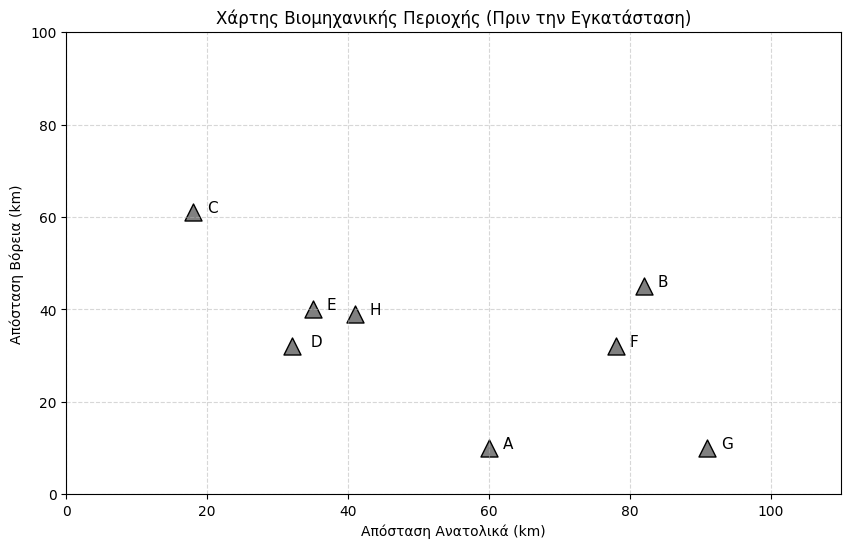

In [ ]:
# --- Block 2: Οπτικοποίηση Χάρτη ---

plt.figure(figsize=(10, 6))
plt.scatter(df['Km_East'], df['Km_North'], s=150, color='gray', edgecolors='black', marker='^')

# Ετικέτες
for i, txt in enumerate(df['Factory_ID']):
    plt.annotate(txt, (df['Km_East'][i]+2, df['Km_North'][i]), fontsize=11)

plt.title("Χάρτης Βιομηχανικής Περιοχής (Πριν την Εγκατάσταση)")
plt.xlabel("Απόσταση Ανατολικά (km)")
plt.ylabel("Απόσταση Βόρεια (km)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0, 110)
plt.ylim(0, 100)
plt.show()

**Block 3: Το Δενδροδιάγραμμα (Η Λογική της Σύνδεσης)**


Εδώ βλέπουμε το ιστορικό των συγχωνεύσεων.

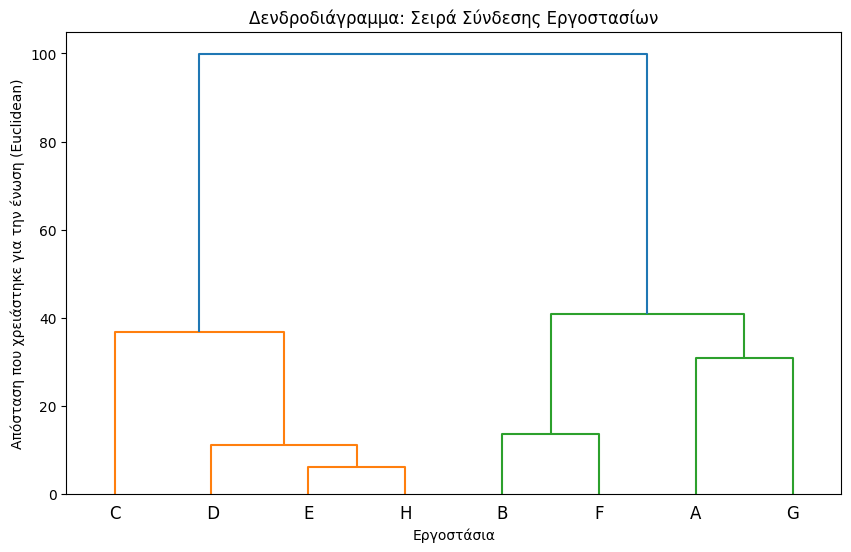

In [ ]:
# --- Block 3: Υπολογισμός & Δενδροδιάγραμμα ---

# Χρησιμοποιούμε 'ward' linkage που είναι το standard για τέτοια προβλήματα
# (ελαχιστοποιεί τη διασπορά της απόστασης μέσα στο cluster)
Z = linkage(X, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(Z, labels=df['Factory_ID'].values)

plt.title("Δενδροδιάγραμμα: Σειρά Σύνδεσης Εργοστασίων")
plt.ylabel("Απόσταση που χρειάστηκε για την ένωση (Euclidean)")
plt.xlabel("Εργοστάσια")
plt.show()

**Block 4: Εφαρμογή Μοντέλου & Αξιολόγηση**


Αποφασίζουμε το πλήθος των κεραιών (Clusters) που θα τοποθετήσουμε και ελέγχουμε την ποιότητα με Silhouette Score.

In [ ]:
# --- Block 4: Τελική Ομαδοποίηση & Αξιολόγηση ---

# Αποφασίζουμε να δημιουργήσουμε n_antennas Ζώνες Κάλυψης
n_antennas = 2
model = AgglomerativeClustering(n_clusters=n_antennas, linkage='ward')
labels = model.fit_predict(X)

df['Antenna_Zone'] = labels # Αποθήκευση στο DataFrame

# Υπολογισμός Silhouette Score
# 1 = Τέλειος διαχωρισμός, 0 = Επικάλυψη
score = silhouette_score(X, labels)

print(f"Δείκτης Ποιότητας Ομαδοποίησης (Silhouette): {score:.3f}")
print("-" * 40)
print("Πλάνο Εγκατάστασης:")
display(df.sort_values('Antenna_Zone'))

Δείκτης Ποιότητας Ομαδοποίησης (Silhouette): 0.535
----------------------------------------
Πλάνο Εγκατάστασης:


,Factory_ID,Km_East,Km_North,Antenna_Zone
0,Α,60,10,0
1,B,82,45,0
6,G,91,10,0
5,F,78,32,0
3,D,32,32,1
2,C,18,61,1
4,E,35,40,1
7,H,41,39,1


**Block 5: Τελικός Χάρτης Κάλυψης**


Το αποτέλεσμα που θα παρουσιάζαμε στη διοίκηση.

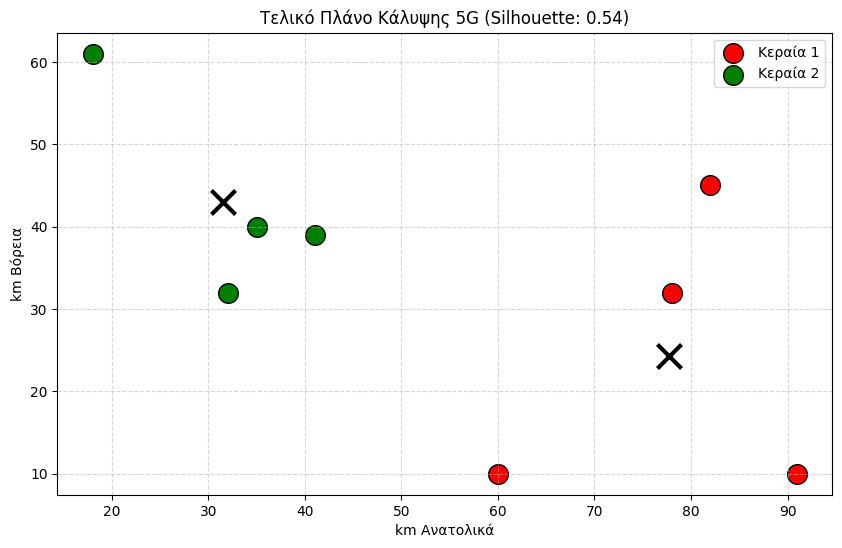

In [ ]:
# --- Block 5: Τελική Οπτικοποίηση Δικτύου ---

plt.figure(figsize=(10, 6))
colors = ['red', 'green', 'blue']

for zone_id in range(n_antennas):
    zone_data = df[df['Antenna_Zone'] == zone_id]
    plt.scatter(zone_data['Km_East'], zone_data['Km_North'],
                s=200, c=colors[zone_id], label=f'Κεραία {zone_id + 1}', edgecolors='black')

# Κέντρα (Centroids) για να δείξουμε πού θα μπει η κεραία περίπου
for zone_id in range(n_antennas):
    center_x = df[df['Antenna_Zone'] == zone_id]['Km_East'].mean()
    center_y = df[df['Antenna_Zone'] == zone_id]['Km_North'].mean()
    plt.scatter(center_x, center_y, marker='x', s=300, c='black', linewidth=3)

plt.title(f"Τελικό Πλάνο Κάλυψης 5G (Silhouette: {score:.2f})")
plt.xlabel("km Ανατολικά")
plt.ylabel("km Βόρεια")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Block 6: Πείραμα με Linkages (Single vs Complete vs Ward)**


Εκπαιδευτικό block για να δούμε πώς αλλάζει το αποτέλεσμα αν αλλάξουμε τον κανόνα απόστασης.

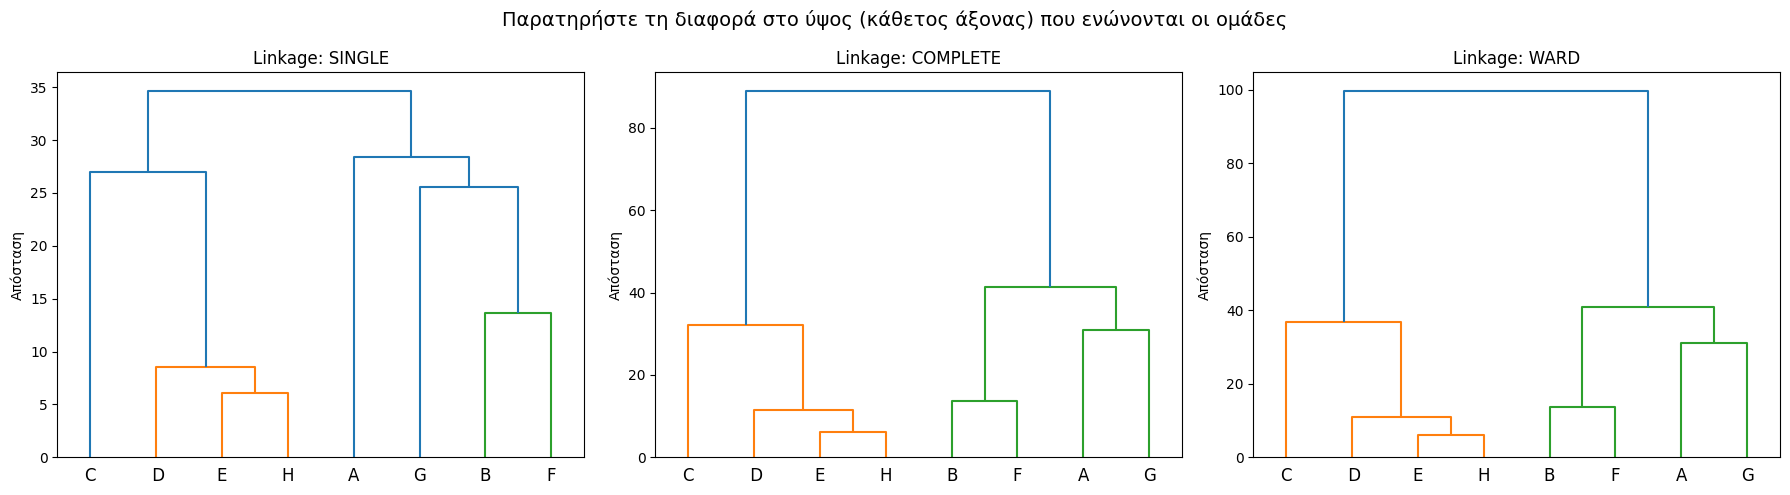

In [ ]:
# --- Block 6: Σύγκριση Μεθόδων (Πώς επηρεάζει ο κανόνας απόστασης;) ---

methods = ['single', 'complete', 'ward']
plt.figure(figsize=(18, 5))

for i, method in enumerate(methods):
    plt.subplot(1, 3, i + 1)
    # Προσοχή: Το ward δουλεύει μόνο με ευκλείδεια απόσταση
    Z_temp = linkage(X, method=method)
    dendrogram(Z_temp, labels=df['Factory_ID'].values)
    plt.title(f"Linkage: {method.upper()}")
    plt.ylabel("Απόσταση")

plt.suptitle("Παρατηρήστε τη διαφορά στο ύψος (κάθετος άξονας) που ενώνονται οι ομάδες", fontsize=14)
plt.tight_layout()
plt.show()